In [81]:
from __future__ import annotations
from typing import Iterable, Callable

from tqdm import tqdm
import concurrent.futures

import random
import numpy as np
import pandas as pd
from math import log
import networkx as nx
from scipy.stats import pearsonr
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

from freyrelab.regnets import regnet
from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet
from freyrelab.nets import models, dissimilarity

from multiprocessing import cpu_count

from dvalue_paral import run_parallel, run_d	

In [82]:
workers = cpu_count()-2
workers

14

In [83]:
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids)

regnet_ids

{'100226_v2019_sA22-DBSCR15_eStrong',
 '158878_v2015_sRTB13',
 '158879_v2015_sRTB13',
 '160491_v2015_sRTB13',
 '186103_v2015_sRTB13',
 '196620_v2015_sRTB13',
 '196627_v2020_s21_eStrong',
 '198466_v2015_sRTB13',
 '199310_v2015_sRTB13',
 '208964_v2020_sRPA20_eStrong',
 '224308_v2008_sDBTBS08_eStrong',
 '273036_v2015_sRTB13',
 '282458_v2015_sRTB13',
 '282459_v2015_sRTB13',
 '301447_v2015_sRTB13',
 '316385_v2015_sRTB13',
 '319701_v2015_sRTB13',
 '331111_v2015_sRTB13',
 '331112_v2015_sRTB13',
 '340184_v2015_sRTB13',
 '344601_v2015_sRTB13',
 '359786_v2015_sRTB13',
 '359787_v2015_sRTB13',
 '362663_v2015_sRTB13',
 '364106_v2015_sRTB13',
 '367830_v2015_sRTB13',
 '370551_v2015_sRTB13',
 '370552_v2015_sRTB13',
 '370554_v2015_sRTB13',
 '381754_v2015_sRTB13',
 '405955_v2015_sRTB13',
 '406558_v2015_sRTB13',
 '418127_v2015_sRTB13',
 '426430_v2015_sRTB13',
 '439855_v2015_sRTB13',
 '451516_v2015_sRTB13',
 '478008_v2015_sRTB13',
 '481805_v2015_sRTB13',
 '487214_v2015_sRTB13',
 '511145_v2022_sRDB22_eStro

In [87]:
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available


regnet_ids = {'100226_v2019_sA22-DBSCR15_eStrong', # debug
 '158878_v2015_sRTB13',
 '158879_v2015_sRTB13',
 '160491_v2015_sRTB13'}

regnets = abasy.regnet(regnet_ids)                      # get the regnets {regnet_id: RegNet}


seed = 42
random.seed(seed)
random_graph = {}
hm_seed_size = 3

for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.DiGraph(nx.scale_free_graph(n, seed=seed))
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)

networks = {**regnets, **random_graph}
networks = {name: RegNet(G) if not isinstance(G, (nx.DiGraph,RegNet)) else G for name, G in networks.items()}

In [88]:
# # networks = {str(i):nx.erdos_renyi_graph(100, 0.2) for i in range(100)}
network_names = list(networks.keys())
combs = list(combinations(network_names, 2))
data = [
    combs,
    [(networks[n1], networks[n2]) for n1, n2 in combs],
]
results = run_parallel(run_d, data, workers)

190it [00:22,  8.53it/s]                     


In [89]:
corr_df = pd.DataFrame(index=network_names, columns=network_names)

for (net1, net2), d in results.items():
    corr_df.loc[net1, net2] = d
    corr_df.loc[net2, net1] = d

corr_df = corr_df.astype(float).fillna(0)
corr_df#.to_csv("dissimilarity_abasy_.csv")

,100226_v2019_sA22-DBSCR15_eStrong,158878_v2015_sRTB13,158879_v2015_sRTB13,160491_v2015_sRTB13,BA_100226_v2019_sA22-DBSCR15_eStrong,SF_100226_v2019_sA22-DBSCR15_eStrong,ER_100226_v2019_sA22-DBSCR15_eStrong,HM_100226_v2019_sA22-DBSCR15_eStrong,BA_158878_v2015_sRTB13,SF_158878_v2015_sRTB13,ER_158878_v2015_sRTB13,HM_158878_v2015_sRTB13,BA_158879_v2015_sRTB13,SF_158879_v2015_sRTB13,ER_158879_v2015_sRTB13,HM_158879_v2015_sRTB13,BA_160491_v2015_sRTB13,SF_160491_v2015_sRTB13,ER_160491_v2015_sRTB13,HM_160491_v2015_sRTB13
100226_v2019_sA22-DBSCR15_eStrong,0.000000,0.162573,0.160805,0.156740,0.336709,0.306245,0.256627,0.318068,0.346419,0.320240,0.226804,0.318068,0.347433,0.320719,0.254803,0.318068,0.370851,0.336054,0.216095,0.328419
158878_v2015_sRTB13,0.162573,0.000000,0.024597,0.191599,0.303395,0.211294,0.332484,0.272841,0.302047,0.198746,0.282355,0.272841,0.297823,0.201360,0.310276,0.272841,0.276307,0.221454,0.280779,0.258117
158879_v2015_sRTB13,0.160805,0.024597,0.000000,0.191924,0.319688,0.223737,0.338269,0.287227,0.318292,0.213015,0.296504,0.287227,0.313931,0.210920,0.316829,0.287227,0.290768,0.233838,0.290918,0.271241
160491_v2015_sRTB13,0.156740,0.191599,0.191924,0.000000,0.373971,0.327857,0.256493,0.302000,0.378771,0.326065,0.230298,0.302000,0.377207,0.325841,0.238551,0.302000,0.363526,0.293380,0.158714,0.311282
BA_100226_v2019_sA22-DBSCR15_eStrong,0.336709,0.303395,0.319688,0.373971,0.000000,0.233136,0.425937,0.300658,0.032282,0.235474,0.319344,0.300658,0.039419,0.236225,0.352134,0.300658,0.154109,0.252578,0.342031,0.296987
SF_100226_v2019_sA22-DBSCR15_eStrong,0.306245,0.211294,0.223737,0.327857,0.233136,0.000000,0.378980,0.258011,0.226435,0.016872,0.340100,0.258011,0.217914,0.017394,0.366994,0.258011,0.131420,0.065773,0.341530,0.232291
ER_100226_v2019_sA22-DBSCR15_eStrong,0.256627,0.332484,0.338269,0.256493,0.425937,0.378980,0.000000,0.404364,0.436739,0.392615,0.182882,0.404364,0.437310,0.393278,0.142326,0.404364,0.450684,0.411539,0.165746,0.429210
HM_100226_v2019_sA22-DBSCR15_eStrong,0.318068,0.272841,0.287227,0.302000,0.300658,0.258011,0.404364,0.000000,0.301315,0.256123,0.342909,0.000000,0.299464,0.255673,0.367830,0.000000,0.276931,0.236601,0.332426,0.094033
BA_158878_v2015_sRTB13,0.346419,0.302047,0.318292,0.378771,0.032282,0.226435,0.436739,0.301315,0.000000,0.225288,0.331189,0.301315,0.012350,0.226050,0.362650,0.301315,0.142009,0.244519,0.352735,0.296411
SF_158878_v2015_sRTB13,0.320240,0.198746,0.213015,0.326065,0.235474,0.016872,0.392615,0.256123,0.225288,0.000000,0.327567,0.256123,0.216765,0.003672,0.356298,0.256123,0.130428,0.061221,0.339752,0.229991


In [72]:
import time
import psutil
from functools import wraps
import networkx as nx
import pandas as pd


def measure_time_and_memory_pairwise(func):
    @wraps(func)
    def wrapper(networks, *args, **kwargs):
        num_networks = len(networks)
        time_data = {'AvgNodes': [], 'AvgEdges': [], 'Time': []}
        memory_data = {'AvgNodes': [], 'AvgEdges': [], 'Memory': []}

        for net_name_1, net_1 in networks.items():
            for net_name_2, net_2 in networks.items():
                if net_name_1 != net_name_2:
                    avg_nodes = (len(net_1.nodes) + len(net_2.nodes)) / 2
                    avg_edges = (len(net_1.edges) + len(net_2.edges)) / 2

                    start_time = time.time()
                    start_memory = psutil.virtual_memory().used

                    result = func(net_1, net_2, *args, **kwargs)

                    end_time = time.time()
                    end_memory = psutil.virtual_memory().used

                    time_data['AvgNodes'].append(avg_nodes)
                    time_data['AvgEdges'].append(avg_edges)
                    time_data['Time'].append(end_time - start_time)

                    memory_data['AvgNodes'].append(avg_nodes)
                    memory_data['AvgEdges'].append(avg_edges)
                    memory_data['Memory'].append(end_memory - start_memory)

        time_df = pd.DataFrame(time_data)
        memory_df = pd.DataFrame(memory_data)

        return time_df, memory_df

    return wrapper
# Example similarity function
@measure_time_and_memory_pairwise
def compute_similarity_pairwise(network1, network2):
    # Your pairwise similarity computation code here
    similarity = dissimilarity.graph_dissimilarity(network1, network2)
    return similarity



In [76]:
# networks = {str(i): nx.erdos_renyi_graph(100, 0.1, directed=True) for i in range(10)}
networks = {}
num_nodes_range = range(100, 601, 200)  # Step of 100
density_range = [i / 100 for i in range(1, 7, 2)]  # Step of 0.02

for num_nodes in num_nodes_range:
    for density in density_range:
        network_name = f"{num_nodes}_{density:.2f}"
        networks[network_name] = nx.erdos_renyi_graph(num_nodes, density, directed=True)
    
len(networks)

9

In [77]:
# Call the decorated function to measure time and memory
time_df, memory_df = compute_similarity_pairwise(networks)

print("Time DataFrame:")
print(time_df)

print("Memory DataFrame:")
print(memory_df)

Time DataFrame:
    AvgNodes  AvgEdges      Time
0      100.0     195.0  0.051382
1      100.0     297.0  0.049934
2      200.0     509.0  0.791639
3      200.0    1390.5  0.408114
4      200.0    2267.0  0.147275
..       ...       ...       ...
67     400.0    6656.0  0.809061
68     400.0    7537.5  0.709803
69     400.0    8414.0  0.864394
70     500.0    7442.0  1.207746
71     500.0    9894.0  1.471974

[72 rows x 3 columns]
Memory DataFrame:
    AvgNodes  AvgEdges     Memory
0      100.0     195.0   -2744320
1      100.0     297.0   -1142784
2      200.0     509.0 -703397888
3      200.0    1390.5    7798784
4      200.0    2267.0    2445312
..       ...       ...        ...
67     400.0    6656.0   -3100672
68     400.0    7537.5    9867264
69     400.0    8414.0  -19058688
70     500.0    7442.0  -11476992
71     500.0    9894.0   -8564736

[72 rows x 3 columns]


In [78]:
time_df

,AvgNodes,AvgEdges,Time
0,100.0,195.0,0.051382
1,100.0,297.0,0.049934
2,200.0,509.0,0.791639
3,200.0,1390.5,0.408114
4,200.0,2267.0,0.147275
...,...,...,...
67,400.0,6656.0,0.809061
68,400.0,7537.5,0.709803
69,400.0,8414.0,0.864394
70,500.0,7442.0,1.207746


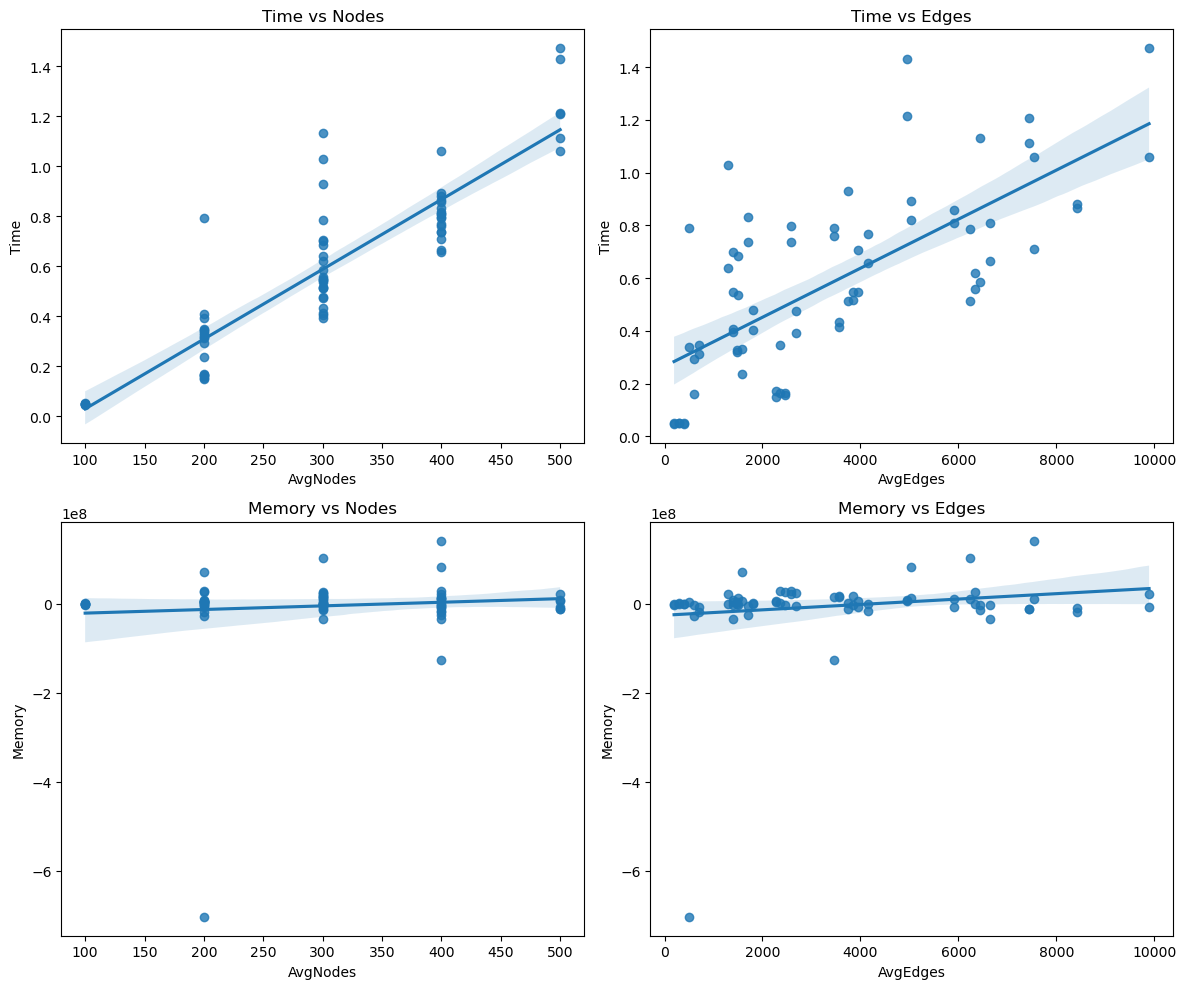

In [80]:
import seaborn as sns


# Create scatter plots with linear regression lines
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

sns.regplot(x='AvgNodes', y='Time', data=time_df, ax=axes[0, 0])
axes[0, 0].set_title('Time vs Nodes')

sns.regplot(x='AvgEdges', y='Time', data=time_df, ax=axes[0, 1])
axes[0, 1].set_title('Time vs Edges')

sns.regplot(x='AvgNodes', y='Memory', data=memory_df, ax=axes[1, 0])
axes[1, 0].set_title('Memory vs Nodes')

sns.regplot(x='AvgEdges', y='Memory', data=memory_df, ax=axes[1, 1])
axes[1, 1].set_title('Memory vs Edges')

plt.tight_layout()
plt.show()

In [ ]:
# Plot boxplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

time_df.boxplot(by=['Nodes'], column=['Time'], ax=axes[0])
axes[0].set_title('Time vs Nodes')

memory_df.boxplot(by=['Nodes'], column=['Memory'], ax=axes[1])
axes[1].set_title('Memory vs Nodes')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
memory_df.loc[:,"Memory"].values

array([  221184,   229376,   286720,    94208,    65536,   278528,
          -4096,   606208,   -94208, -5197824,  3354624,  1282048,
       -5357568,  5238784,   -40960,   -32768,   -12288,   139264,
         -90112,   -20480,   159744,  -118784,  8585216,        0,
              0, -1904640,  -425984,  -532480,  -176128,  -339968,
         -65536,  -196608,   -32768, -3567616,  7573504,   -40960,
         -57344,        0,  -241664,  -147456,   -32768, -3129344,
              0,        0,        0,   -28672,   -24576,  -962560,
        -225280,  3543040,        0,   -73728,  -327680,   -61440,
              0, -5214208, -2416640, -1294336,  2637824,        0,
           4096,    36864,   -57344,  -180224,  9375744,        0,
         -12288,  -126976,        0,   -65536,  -770048,    -8192,
       -1748992,        0,        0,     4096,     4096,   102400,
       -1298432,  8622080,  -155648,        0, -1155072,        0,
        -974848,  -729088,        0,        0,  -208896,      

In [12]:
networks = {str(i):nx.erdos_renyi_graph(100, 0.2) for i in range(100)}

In [13]:
network_names = networks.keys()
corr_df = pd.DataFrame(index=network_names, columns=network_names)

for net1, net2 in combinations(network_names, 2):
    d = dissimilarity.graph_dissimilarity(networks[net1], networks[net2])
    corr_df.loc[net1, net2] = d
    corr_df.loc[net2, net1] = d

corr_df = corr_df.astype(float).fillna(0)
#corr_df.to_csv("dissimilarity.csv")

ValueError: math domain error